In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn.model_selection as model_selection
import sklearn.metrics as metrics

df_bruto= pd.read_csv('sinasc_pa_2026.csv')
df_bruto.head(5)


,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,TPDOCRESP,DTDECLARAC,ESCMAEAGR1,STDNEPIDEM,STDNNOVA,CODPAISRES,TPROBSON,PARIDADE,KOTELCHUCK,CONTADOR
0,1,2515598.0,110002,1,34,2.0,4.0,622020.0,1.0,2.0,...,3.0,20042026.0,6.0,1,1,1,5,1,2,555
1,1,2013282.0,130014,1,24,1.0,4.0,999992.0,0.0,0.0,...,3.0,9042026.0,4.0,1,1,1,2,0,5,23568
2,1,2013282.0,130014,1,27,1.0,4.0,622020.0,2.0,0.0,...,3.0,7082026.0,6.0,1,1,1,3,1,5,23642
3,1,2012480.0,130260,1,28,1.0,4.0,516115.0,1.0,0.0,...,4.0,2032026.0,6.0,1,1,1,3,1,5,37006
4,1,3151794.0,130260,1,18,1.0,4.0,631105.0,1.0,0.0,...,5.0,20022026.0,6.0,1,1,1,3,1,2,37693


In [2]:
colunas = ["CODMUNRES", "CODMUNNASC", "LOCNASC", "IDADEMAE", "ESTCIVMAE", "ESCMAE", "QTDFILVIVO", "GESTACAO", "GRAVIDEZ", "PARTO", "CONSULTAS", "DTNASC", "SEXO", "APGAR5", "RACACOR", "PESO", "SEMAGESTAC", "CONSPRENAT"]
df = df_bruto[colunas].copy()
df.isna().sum()

CODMUNRES        0
CODMUNNASC       0
LOCNASC          0
IDADEMAE         0
ESTCIVMAE      204
ESCMAE         801
QTDFILVIVO     703
GESTACAO       918
GRAVIDEZ        59
PARTO           50
CONSULTAS        0
DTNASC           0
SEXO             0
APGAR5         892
RACACOR        399
PESO            16
SEMAGESTAC     918
CONSPRENAT    1014
dtype: int64

In [3]:
print('Quantidade linhas - colunas: ')
df.shape

Quantidade linhas - colunas: 


(73461, 18)

## Tratamento dos dados

No SINASC os valores ignorados vêm como código (9, 99 ou 0) e não como vazio. Se eu deixasse assim, o 99 de QTDFILVIVO, por exemplo, entraria na média como se fosse 99 filhos. Por isso troquei esses códigos por NaN. A data também precisou de ajuste porque foi lida como número e perdeu o zero da frente.

In [4]:
df['DTNASC'] = pd.to_datetime(df['DTNASC'].astype(str).str.zfill(8), format='%d%m%Y')

df['ESTCIVMAE'] = df['ESTCIVMAE'].replace(9, np.nan)
df['ESCMAE'] = df['ESCMAE'].replace(9, np.nan)
df['CONSULTAS'] = df['CONSULTAS'].replace(9, np.nan)
df['GRAVIDEZ'] = df['GRAVIDEZ'].replace(9, np.nan)
df['LOCNASC'] = df['LOCNASC'].replace(9, np.nan)
df['SEXO'] = df['SEXO'].replace(0, np.nan)
df['QTDFILVIVO'] = df['QTDFILVIVO'].replace(99, np.nan)
df['APGAR5'] = df['APGAR5'].replace(99, np.nan)
df['CONSPRENAT'] = df['CONSPRENAT'].replace(99, np.nan)

df.isna().mean().mul(100).round(2).sort_values(ascending=False)

CONSPRENAT    3.04
ESCMAE        1.90
CONSULTAS     1.66
GESTACAO      1.25
SEMAGESTAC    1.25
APGAR5        1.22
QTDFILVIVO    0.96
RACACOR       0.54
ESTCIVMAE     0.48
GRAVIDEZ      0.08
PARTO         0.07
SEXO          0.02
PESO          0.02
CODMUNRES     0.00
CODMUNNASC    0.00
LOCNASC       0.00
IDADEMAE      0.00
DTNASC        0.00
dtype: float64

### Comparação entre linhas completas e incompletas

Se eu apagasse todas as linhas que têm algum ausente, perderia uma parte pequena da base. Mesmo assim, ter muitos dados só garante que os intervalos continuam precisos. Não garante que quem foi apagado seja parecido com quem ficou. Por isso comparei os dois grupos antes de decidir.

In [5]:
incompleta = df.isna().any(axis=1)

print(f'Linhas com algum ausente: {incompleta.sum()} ({incompleta.mean() * 100:.1f}%)')
print(f'Linhas completas: {(~incompleta).sum()}')

Linhas com algum ausente: 5694 (7.8%)
Linhas completas: 67767


In [6]:
comparacao = pd.DataFrame({
    'PESO médio': df.groupby(incompleta)['PESO'].mean(),
    'IDADEMAE média': df.groupby(incompleta)['IDADEMAE'].mean(),
    '% cesárea': df['PARTO'].map({1: 0, 2: 1}).groupby(incompleta).mean() * 100,
    '% nasceu fora do município': (df['CODMUNRES'] != df['CODMUNNASC']).groupby(incompleta).mean() * 100,
})
comparacao.index = ['Completas', 'Com algum ausente']
comparacao.round(2)

,PESO médio,IDADEMAE média,% cesárea,% nasceu fora do município
Completas,3188.12,25.87,63.63,26.93
Com algum ausente,3156.77,25.97,59.37,31.74


In [7]:
peso_completas = df.loc[~incompleta, 'PESO'].dropna()
peso_incompletas = df.loc[incompleta, 'PESO'].dropna()

resultado = stats.ttest_ind(peso_completas, peso_incompletas, equal_var=False)

dif = peso_completas.mean() - peso_incompletas.mean()
desvio_comum = np.sqrt(((len(peso_completas) - 1) * peso_completas.var(ddof=1) + (len(peso_incompletas) - 1) * peso_incompletas.var(ddof=1)) / (len(peso_completas) + len(peso_incompletas) - 2))

print(f'diferença de peso médio = {dif:.2f} g | t = {resultado.statistic:.2f} | p-valor = {resultado.pvalue:.3e} | d = {dif / desvio_comum:.3f}')

diferença de peso médio = 31.35 g | t = 3.93 | p-valor = 8.664e-05 | d = 0.056


In [8]:
peso_todos = df['PESO'].dropna()

dist = stats.t(df=len(peso_todos) - 1, loc=peso_todos.mean(), scale=stats.sem(peso_todos))
inf, sup = dist.interval(0.95)
print(f'IC 95% do peso médio, todas as linhas: [{inf:.2f}, {sup:.2f}]')

dist = stats.t(df=len(peso_completas) - 1, loc=peso_completas.mean(), scale=stats.sem(peso_completas))
inf, sup = dist.interval(0.95)
print(f'IC 95% do peso médio, só linhas completas: [{inf:.2f}, {sup:.2f}]')

IC 95% do peso médio, todas as linhas: [3181.66, 3189.73]
IC 95% do peso médio, só linhas completas: [3183.93, 3192.30]


As linhas incompletas têm peso médio cerca de 31 g menor (3157 g contra 3188 g). Com tantos dados o teste dá p-valor pequeno, mas o d de Cohen é de só 0,056, ou seja, a diferença quase não tem importância na prática. O IC do peso médio muda uns 2 g quando uso só as linhas completas. Também há um pouco mais de nascimentos fora do município e um pouco menos de cesáreas entre as incompletas. Como as diferenças são pequenas, apagar essas linhas não deve mudar as conclusões.

### Exclusão das linhas com ausentes

Decidi apagar todas as linhas que têm algum ausente. Perco 7,8% da base e ainda sobram mais de 67 mil linhas. A comparação acima mostrou diferenças pequenas entre os grupos, então a exclusão não deve enviesar os resultados. A precisão quase não muda: o erro padrão aumenta uns 4%, o que é desprezível. A vantagem é usar a mesma base em todas as análises de maneira mais organizada, o que deixa os resultados comparáveis entre si e combina com a regressão, que também só usa linhas completas.

In [9]:
n_antes = len(df)
df = df.dropna().reset_index(drop=True)

print(f'Linhas antes: {n_antes} | depois: {len(df)} | removidas: {n_antes - len(df)} ({(n_antes - len(df)) / n_antes * 100:.1f}%)')
print(f'Ausentes restantes: {df.isna().sum().sum()}')

Linhas antes: 73461 | depois: 67767 | removidas: 5694 (7.8%)
Ausentes restantes: 0


## Remoção de valores impossíveis

Nos extremos do `describe` apareceram valores estranhos (mães de 8 anos, bebês de 125 g, 45 semanas de gestação, 44 consultas). O critério que usei foi: **só removo o que é medicamente impossível ou incoerente entre variáveis**. Se o valor é raro ou difícil, mas possível, eu mantenho, porque são casos reais e, em geral, os mais importantes para a saúde pública. Esse passo vem depois da exclusão dos ausentes, então os números valem para as 67.767 linhas completas.

**O que removi.** O que é impossível é a *combinação* entre peso e semanas, e não o peso sozinho: um bebê de 300 g com 24 semanas é possível, mas com 38 semanas não é.

- 37 semanas ou mais com menos de 1000 g: 93 linhas. A termo, um bebê dessa faixa de peso praticamente não existe. A tabela acima mostra um pico de 65 bebês entre 200 e 400 g, separado do resto da distribuição (só 19 entre 500 e 1000 g), o que parece erro de digitação, como 3150 registrado como 315.
- De 32 a 36 semanas com menos de 500 g: 12 linhas, pelo mesmo motivo.
- Menos de 32 semanas com mais de 4500 g: 2 linhas, porque o peso é incompatível com a idade gestacional.

No total saíram 107 linhas (0,16%). Os limiares (1000 g, 500 g e 4500 g) são escolha minha, baseada nesse aglomerado dos dados e em plausibilidade clínica, e não em uma tabela de referência.

**O que mantive e por quê.**

- Mães com menos de 12 anos (6 linhas, a menor com 8 anos): é raro, mas existe e está documentado (o caso mais jovem já descrito tinha 5 anos).
- Mães com mais de 49 anos (3 linhas): possível, principalmente com reprodução assistida.
- Mais de 30 consultas de pré-natal (38 linhas): uma gestação de alto risco pode ter acompanhamento semanal ou mais frequente.
- Bebês abaixo de 500 g (36 linhas depois da remoção): são prematuros extremos, e há casos de sobrevivência documentados abaixo de 300 g. Os que tinham peso incompatível com as semanas já saíram nas regras acima.
- Mais de 42 semanas (616 linhas): gestação pós-termo prolongada é rara, mas descrita. Parte pode ser erro na data da última menstruação, e isso fica como limitação do estudo.

In [10]:
termo = df[df['SEMAGESTAC'] >= 37]
pd.cut(termo['PESO'], bins=[0, 200, 300, 400, 500, 800, 1000, 1500, 2000, 2500]).value_counts().sort_index()

PESO
(0, 200]           1
(200, 300]        15
(300, 400]        50
(400, 500]         8
(500, 800]        10
(800, 1000]        9
(1000, 1500]      48
(1500, 2000]     229
(2000, 2500]    2145
Name: count, dtype: int64

In [11]:
a_termo = (df['SEMAGESTAC'] >= 37) & (df['PESO'] < 1000)
pre_termo = (df['SEMAGESTAC'] >= 32) & (df['SEMAGESTAC'] < 37) & (df['PESO'] < 500)
muito_pesado = (df['SEMAGESTAC'] < 32) & (df['PESO'] > 4500)
impossivel = a_termo | pre_termo | muito_pesado

print(f'37 semanas ou mais com menos de 1000 g: {a_termo.sum()}')
print(f'32 a 36 semanas com menos de 500 g: {pre_termo.sum()}')
print(f'Menos de 32 semanas com mais de 4500 g: {muito_pesado.sum()}')

n_antes = len(df)
df = df[~impossivel].reset_index(drop=True)

print(f'Linhas antes: {n_antes} | depois: {len(df)} | removidas: {n_antes - len(df)} ({(n_antes - len(df)) / n_antes * 100:.2f}%)')

37 semanas ou mais com menos de 1000 g: 93
32 a 36 semanas com menos de 500 g: 12
Menos de 32 semanas com mais de 4500 g: 2
Linhas antes: 67767 | depois: 67660 | removidas: 107 (0.16%)


In [12]:
pd.Series({
    'Mães com menos de 12 anos': (df['IDADEMAE'] < 12).sum(),
    'Mães com mais de 49 anos': (df['IDADEMAE'] > 49).sum(),
    'Mais de 30 consultas de pré-natal': (df['CONSPRENAT'] > 30).sum(),
    'Peso abaixo de 500 g': (df['PESO'] < 500).sum(),
    'Mais de 42 semanas de gestação': (df['SEMAGESTAC'] > 42).sum(),
})

Mães com menos de 12 anos              6
Mães com mais de 49 anos               3
Mais de 30 consultas de pré-natal     38
Peso abaixo de 500 g                  36
Mais de 42 semanas de gestação       616
dtype: int64

## Criação de variáveis

Criei variáveis binárias para poder trabalhar com proporções: cesárea, baixo peso (menos de 2500 g), prematuro (menos de 37 semanas) e pré-natal adequado (6 consultas ou mais, que é o mínimo do Ministério da Saúde). Também criei mãe adolescente (menos de 20 anos) e uma variável que marca se o bebê nasceu em município diferente do de residência.

In [13]:
df['SEXO_DESC'] = df['SEXO'].map({1: 'Masculino', 2: 'Feminino'})
df['CESAREA'] = df['PARTO'].map({1: 0, 2: 1})

df['BAIXO_PESO'] = (df['PESO'] < 2500).astype(float).where(df['PESO'].notna())
df['PREMATURO'] = (df['SEMAGESTAC'] < 37).astype(float).where(df['SEMAGESTAC'].notna())
df['PRENATAL_ADEQUADO'] = (df['CONSPRENAT'] >= 6).astype(float).where(df['CONSPRENAT'].notna())

df['MAE_ADOLESCENTE'] = (df['IDADEMAE'] < 20).astype(int)
df['FAIXA_IDADE_MAE'] = pd.cut(df['IDADEMAE'], bins=[0, 19, 34, 100], labels=['Até 19', '20 a 34', '35 ou mais'])
df['CONSULTAS_DESC'] = df['CONSULTAS'].map({1: 'Nenhuma', 2: '1 a 3', 3: '4 a 6', 4: '7 ou mais'})

df['NASCEU_FORA_MUN_RES'] = (df['CODMUNRES'] != df['CODMUNNASC']).astype(int)

df[['CESAREA', 'BAIXO_PESO', 'PREMATURO', 'PRENATAL_ADEQUADO', 'MAE_ADOLESCENTE', 'NASCEU_FORA_MUN_RES']].mean().round(4)

CESAREA                0.6365
BAIXO_PESO             0.0829
PREMATURO              0.1301
PRENATAL_ADEQUADO      0.7954
MAE_ADOLESCENTE        0.1838
NASCEU_FORA_MUN_RES    0.2692
dtype: float64

## Análise exploratória

In [14]:
df[['PESO', 'SEMAGESTAC', 'IDADEMAE', 'CONSPRENAT', 'APGAR5']].describe().round(2)

,PESO,SEMAGESTAC,IDADEMAE,CONSPRENAT,APGAR5
count,67660.00,67660.00,67660.00,67660.00,67660.00
mean,3192.40,38.27,25.87,8.10,9.16
std,545.18,2.27,6.56,3.39,0.82
min,252.00,19.00,8.00,0.00,0.00
25%,2905.00,38.00,21.00,6.00,9.00
50%,3220.00,39.00,25.00,8.00,9.00
75%,3530.00,40.00,30.00,10.00,10.00
max,6990.00,45.00,55.00,44.00,10.00


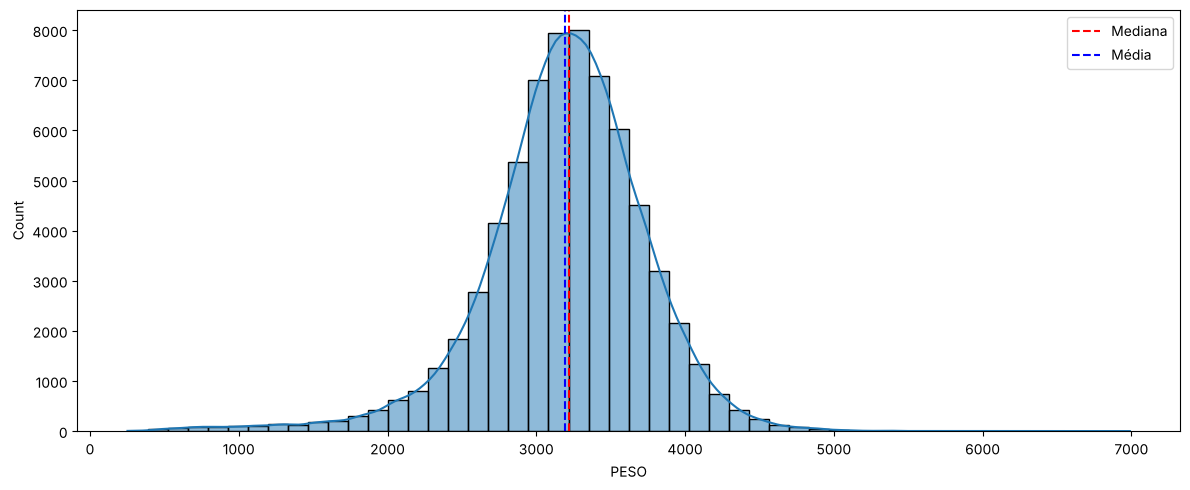

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df['PESO'], bins=50, kde=True)
ax.axvline(x= df['PESO'].median(),linestyle='--',color='red',label='Mediana')
ax.axvline(x= df['PESO'].mean(),linestyle='--',color='blue',label='Média')
plt.legend()
plt.tight_layout()
plt.show()

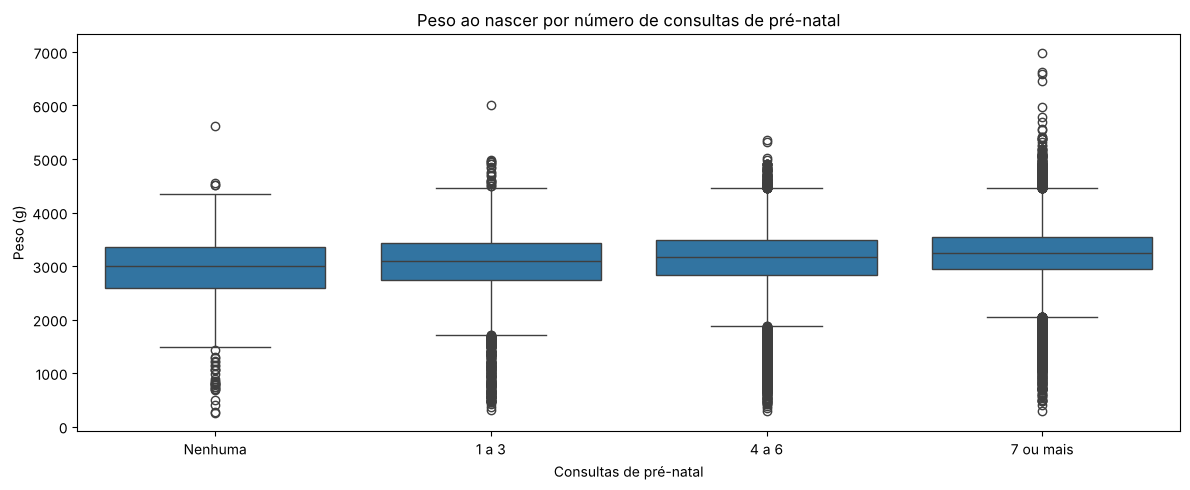

In [16]:
ordem_consultas = ['Nenhuma', '1 a 3', '4 a 6', '7 ou mais']

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='CONSULTAS_DESC', y='PESO', order=ordem_consultas, ax=ax)
ax.set_title('Peso ao nascer por número de consultas de pré-natal')
ax.set_xlabel('Consultas de pré-natal')
ax.set_ylabel('Peso (g)')
plt.tight_layout()
plt.show()

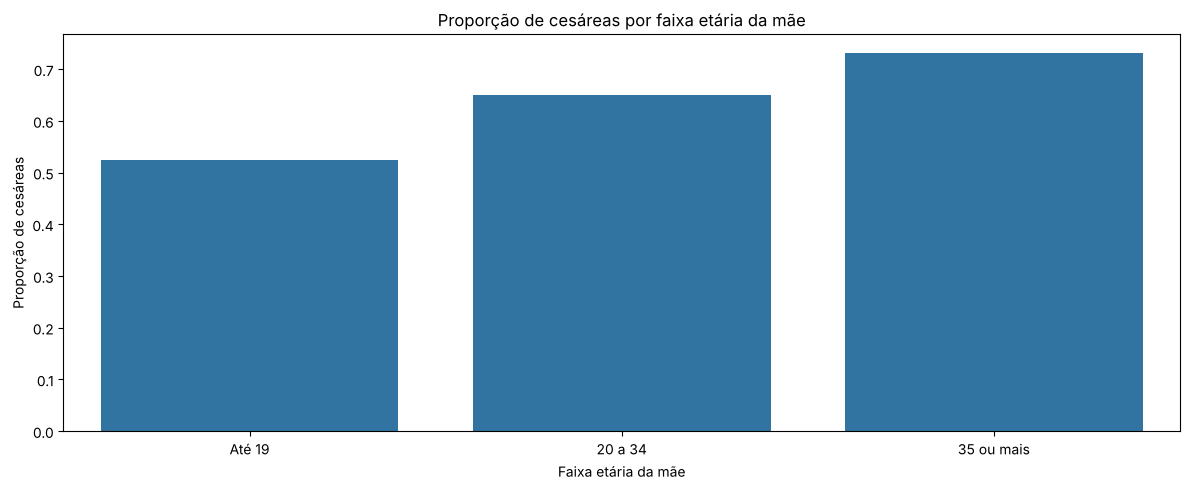

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df, x='FAIXA_IDADE_MAE', y='CESAREA', errorbar=None, ax=ax)
ax.set_title('Proporção de cesáreas por faixa etária da mãe')
ax.set_xlabel('Faixa etária da mãe')
ax.set_ylabel('Proporção de cesáreas')
plt.tight_layout()
plt.show()

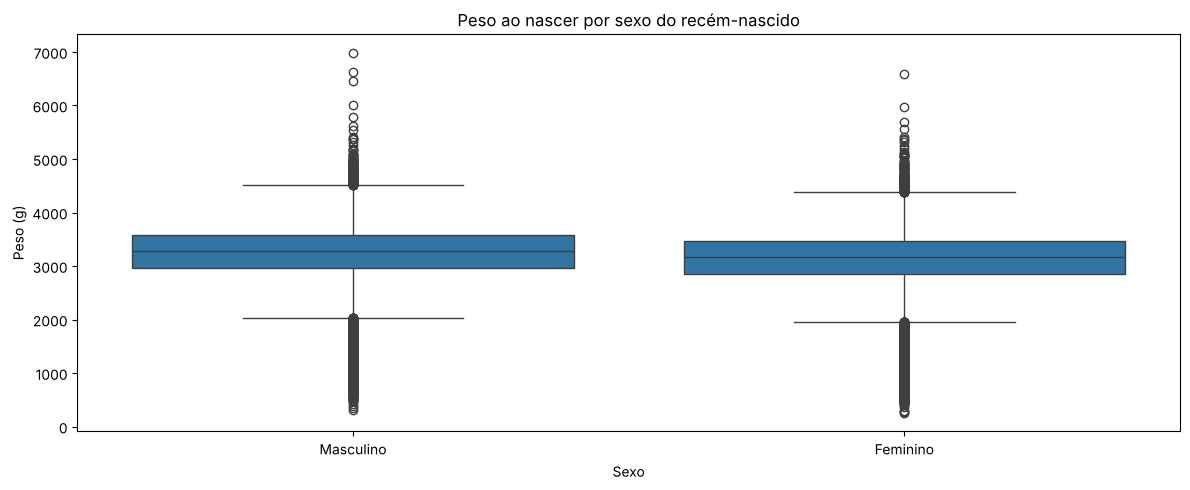

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='SEXO_DESC', y='PESO', ax=ax)
ax.set_title('Peso ao nascer por sexo do recém-nascido')
ax.set_xlabel('Sexo')
ax.set_ylabel('Peso (g)')
plt.tight_layout()
plt.show()

## Pressuposto de normalidade

O IC e o teste t para média pedem que a média amostral seja aproximadamente normal. Com mais de 67 mil observações isso vale pelo Teorema Central do Limite, mesmo com o peso um pouco assimétrico. Não usei Shapiro-Wilk porque com n tão grande ele rejeita a normalidade até para desvios sem importância. Olhei o QQ-plot e a assimetria.

-0.7247956469667238
2.6084234509057307


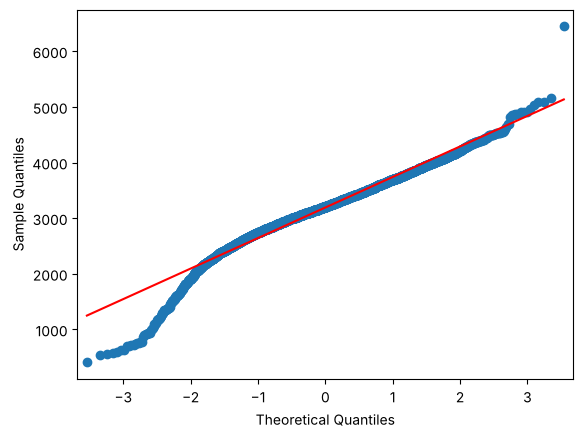

In [19]:
peso = df['PESO'].dropna()

print(stats.skew(peso))
print(stats.kurtosis(peso))

sm.qqplot(peso.sample(5000, random_state=42), line='s')
plt.show()

## Intervalos de confiança

Para a média do peso usei a distribuição t com n - 1 graus de liberdade, porque o desvio padrão da população não é conhecido. Conferi o resultado com um IC por bootstrap, que não depende de pressuposto sobre a distribuição.

In [20]:
n = len(peso)
media = peso.mean()
erro_padrao = stats.sem(peso)

dist = stats.t(df=n - 1, loc=media, scale=erro_padrao)
inf, sup = dist.interval(0.95)

print(f'n = {n} | média = {media:.2f} | erro padrão = {erro_padrao:.3f}')
print(f'IC 95% (t): [{inf:.2f}, {sup:.2f}]')

n = 67660 | média = 3192.40 | erro padrão = 2.096
IC 95% (t): [3188.29, 3196.51]


In [21]:
valores = peso.to_numpy()
rng = np.random.default_rng(42)

medias_boot = []
for i in range(2000):
    amostra = rng.choice(valores, size=len(valores), replace=True)
    medias_boot.append(amostra.mean())

inf_boot, sup_boot = np.percentile(medias_boot, [2.5, 97.5])
print(f'IC 95% (bootstrap): [{inf_boot:.2f}, {sup_boot:.2f}]')

IC 95% (bootstrap): [3188.18, 3196.63]


In [22]:
for coluna in ['CESAREA', 'BAIXO_PESO', 'PREMATURO', 'PRENATAL_ADEQUADO']:
    serie = df[coluna].dropna()
    n = len(serie)
    p = serie.mean()
    erro_padrao = np.sqrt(p * (1 - p) / n)
    dist = stats.norm(loc=p, scale=erro_padrao)
    inf, sup = dist.interval(0.95)
    print(f'{coluna}: p = {p:.4f} | IC 95% = [{inf:.4f}, {sup:.4f}]')

CESAREA: p = 0.6365 | IC 95% = [0.6329, 0.6401]
BAIXO_PESO: p = 0.0829 | IC 95% = [0.0808, 0.0850]
PREMATURO: p = 0.1301 | IC 95% = [0.1275, 0.1326]
PRENATAL_ADEQUADO: p = 0.7954 | IC 95% = [0.7924, 0.7985]


## Relação entre variáveis

O peso ao nascer é a variável dependente, porque é o desfecho mais usado para medir a saúde do recém-nascido. As candidatas a explicativas são as semanas de gestação, o número de consultas de pré-natal, a idade da mãe, a quantidade de filhos vivos, o sexo, o tipo de gravidez e o tipo de parto. Comecei pela correlação de Pearson, que mede a relação linear, e pela de Spearman, que mede a relação monotônica e é menos sensível a valores extremos. Se as duas forem parecidas, a relação não depende de poucos casos extremos.

A correlação de Pearson do peso com as semanas de gestação é 0,46, a maior de todas. Depois vêm a gravidez múltipla (-0,22), o Apgar do 5º minuto (0,20) e as consultas de pré-natal (0,13). Idade da mãe, filhos vivos, sexo e tipo de parto ficam em torno de 0,06 a 0,09. O Apgar é consequência do estado do bebê, e não causa do peso, por isso não entra como explicativa no modelo. As consultas aparecem correlacionadas com as semanas (0,14): quem fica grávida por mais tempo tem mais oportunidades de consulta. Isso significa que parte da relação entre consultas e peso passa pela idade gestacional. Por isso comparo a correlação entre consultas e peso em todos os nascimentos (0,128) com a dos nascimentos a termo (0,073). Quando a idade gestacional deixa de variar tanto, a relação cai, mas não desaparece.

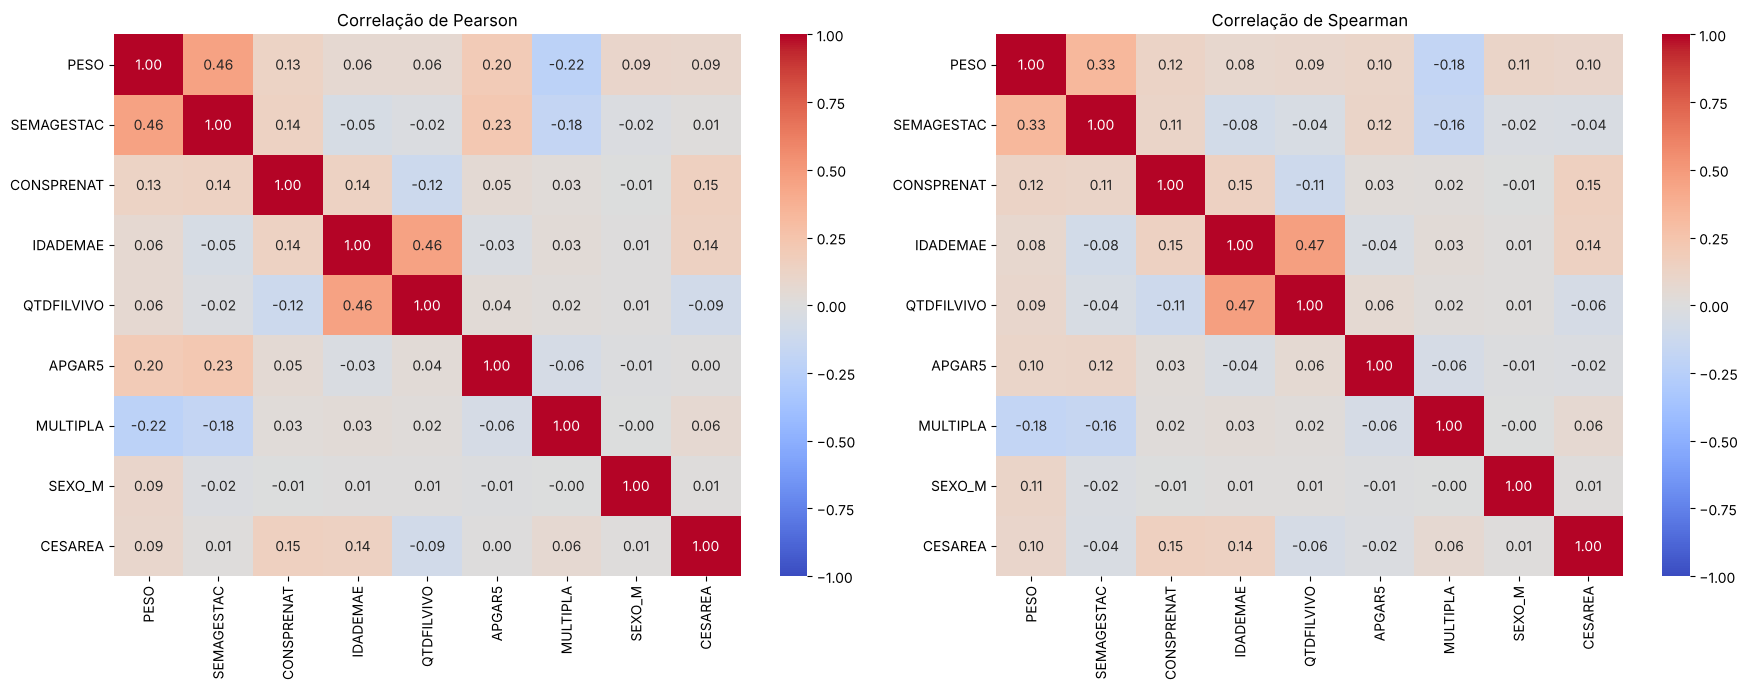

In [23]:
df['MULTIPLA'] = (df['GRAVIDEZ'] > 1).astype(int)
df['SEXO_M'] = (df['SEXO'] == 1).astype(int)
df['MES'] = df['DTNASC'].dt.month
df['GRAVIDEZ_DESC'] = df['MULTIPLA'].map({0: 'Única', 1: 'Múltipla'})
df['SEM_C'] = df['SEMAGESTAC'] - 38
df['SEM_C2'] = df['SEM_C'] ** 2

numericas = ['PESO', 'SEMAGESTAC', 'CONSPRENAT', 'IDADEMAE', 'QTDFILVIVO', 'APGAR5', 'MULTIPLA', 'SEXO_M', 'CESAREA']
corr_pearson = df[numericas].corr()
corr_spearman = df[numericas].corr(method='spearman')

fig, eixos = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=eixos[0])
eixos[0].set_title('Correlação de Pearson')
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=eixos[1])
eixos[1].set_title('Correlação de Spearman')
plt.tight_layout()
plt.show()

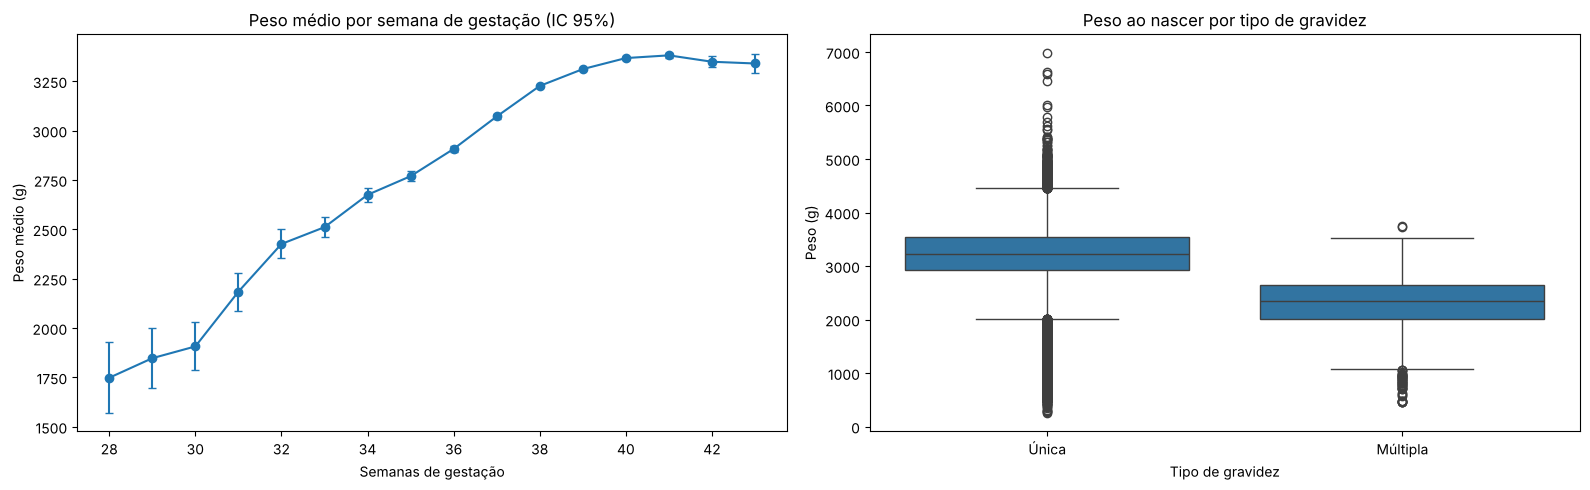

In [24]:
por_semana = df[df['SEMAGESTAC'].between(28, 43)].groupby('SEMAGESTAC')['PESO'].agg(['mean', 'sem', 'count'])
por_semana['ic'] = stats.t.ppf(0.975, por_semana['count'] - 1) * por_semana['sem']

fig, eixos = plt.subplots(1, 2, figsize=(16, 5))
eixos[0].errorbar(por_semana.index, por_semana['mean'], yerr=por_semana['ic'], fmt='o-', capsize=3)
eixos[0].set_title('Peso médio por semana de gestação (IC 95%)')
eixos[0].set_xlabel('Semanas de gestação')
eixos[0].set_ylabel('Peso médio (g)')
sns.boxplot(data=df, x='GRAVIDEZ_DESC', y='PESO', ax=eixos[1])
eixos[1].set_title('Peso ao nascer por tipo de gravidez')
eixos[1].set_xlabel('Tipo de gravidez')
eixos[1].set_ylabel('Peso (g)')
plt.tight_layout()
plt.show()

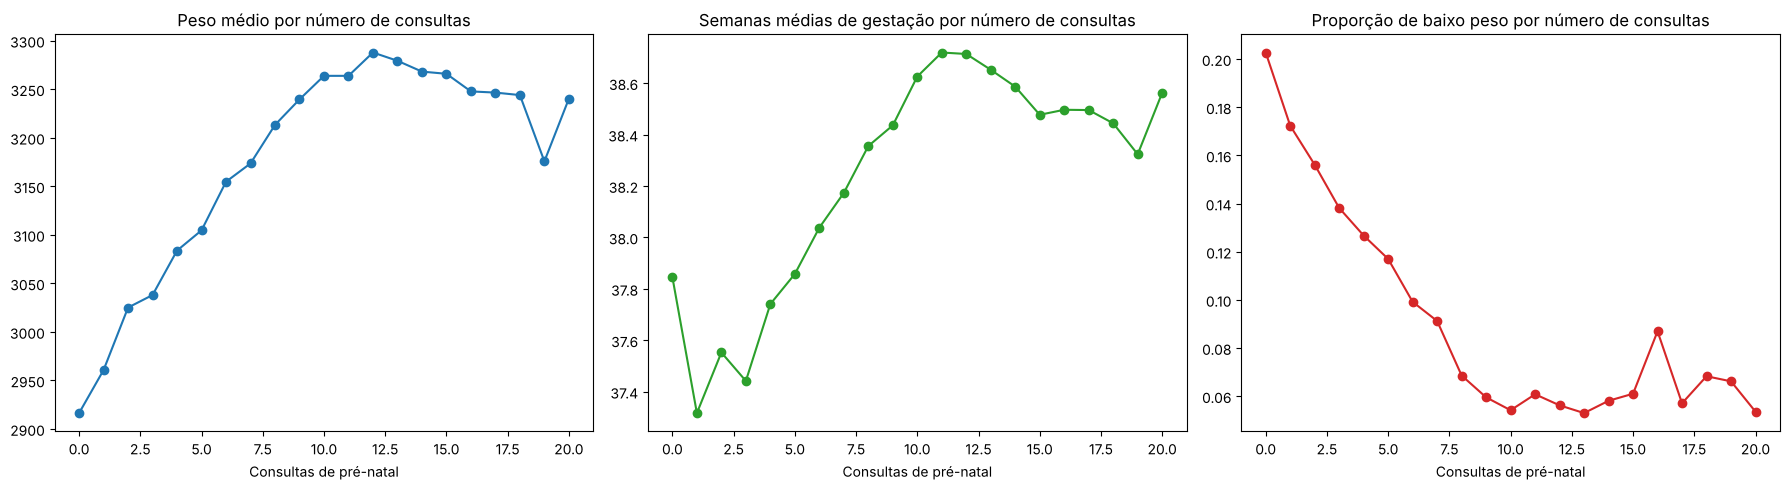

In [25]:
por_consultas = df.groupby('CONSPRENAT').agg(n=('PESO', 'size'), peso=('PESO', 'mean'), semanas=('SEMAGESTAC', 'mean'), baixo_peso=('BAIXO_PESO', 'mean'))
por_consultas = por_consultas[por_consultas['n'] >= 100]

fig, eixos = plt.subplots(1, 3, figsize=(18, 5))
eixos[0].plot(por_consultas.index, por_consultas['peso'], 'o-')
eixos[0].set_title('Peso médio por número de consultas')
eixos[1].plot(por_consultas.index, por_consultas['semanas'], 'o-', color='tab:green')
eixos[1].set_title('Semanas médias de gestação por número de consultas')
eixos[2].plot(por_consultas.index, por_consultas['baixo_peso'], 'o-', color='tab:red')
eixos[2].set_title('Proporção de baixo peso por número de consultas')
for eixo in eixos:
    eixo.set_xlabel('Consultas de pré-natal')
plt.tight_layout()
plt.show()

In [26]:
termo_df = df[df['SEMAGESTAC'] >= 37]
print(f"Correlação peso x consultas (todos): {df['PESO'].corr(df['CONSPRENAT']):.3f}")
print(f"Correlação peso x consultas (37 semanas ou mais): {termo_df['PESO'].corr(termo_df['CONSPRENAT']):.3f}")
print(f"Correlação semanas x consultas (todos): {df['SEMAGESTAC'].corr(df['CONSPRENAT']):.3f}")

Correlação peso x consultas (todos): 0.128
Correlação peso x consultas (37 semanas ou mais): 0.073
Correlação semanas x consultas (todos): 0.136


## Hipóteses e testes

Cada hipótese abaixo nasceu de um padrão visto na análise exploratória. Todas usam nível de significância de 5%, e como são 7 testes feitos na mesma base apliquei a correção de Bonferroni, que divide o alfa pelo número de testes (0,05 / 7 = 0,0071) para controlar a chance de rejeitar H0 por acaso em algum deles. Para cada teste apresento a estatística, os graus de liberdade, o p-valor, o tamanho de efeito e o intervalo de confiança de 95% da diferença. Com n próximo de 68 mil quase qualquer diferença dá p-valor pequeno, então o tamanho de efeito e o IC são o que indica se a diferença tem importância prática.

| Hipótese | H0 | H1 | Teste | Motivação na exploração |
|---|---|---|---|---|
| H1 | O peso médio é igual entre meninos e meninas | O peso médio é diferente | t de Welch | Boxplot por sexo |
| H2 | A proporção de baixo peso é igual com pré-natal adequado e inadequado | As proporções são diferentes | Qui-quadrado 2x2 | Peso cresce com o número de consultas |
| H3 | A proporção de cesárea é igual entre adolescentes e demais mães | As proporções são diferentes | Qui-quadrado 2x2 | Gráfico de cesárea por faixa etária |
| H4 | O peso médio é igual nas quatro faixas de consultas | Pelo menos uma média é diferente | ANOVA, Kruskal-Wallis e t de Welch par a par | Boxplot por consultas |
| H5 | O peso médio é igual em gravidez única e múltipla | O peso médio é diferente | t de Welch | Correlação de -0,22 com o peso |
| H6 | A prematuridade é igual para quem nasce dentro e fora do município de residência | As proporções são diferentes | Qui-quadrado 2x2 | Diferença entre linhas completas e incompletas no local de nascimento |
| H7 | A proporção de pré-natal inadequado é igual nos 8 maiores municípios | Pelo menos um município é diferente | Qui-quadrado 8x2 | Variação entre municípios na tabela descritiva |

Os testes t usam a versão de Welch porque os grupos têm tamanhos e variâncias muito diferentes (H5 compara 1.167 gestações múltiplas com 66.493 únicas). Na ANOVA, o teste de Levene rejeita a igualdade das variâncias, então confirmei o resultado com Kruskal-Wallis, que não exige normalidade nem variâncias iguais, e usei testes t de Welch par a par, com correção de Bonferroni (6 comparações, alfa de 0,05 / 6 = 0,0083 cada), para saber quais pares diferem. O Welch não supõe variâncias iguais, o que combina com o resultado do Levene.

In [ ]:
from itertools import combinations

alfa = 0.05
n_testes = 7
alfa_ajustado = alfa / n_testes

def ic_dif_medias(a, b, nivel=0.95):
    dif = a.mean() - b.mean()
    va = a.var(ddof=1) / len(a)
    vb = b.var(ddof=1) / len(b)
    ep = np.sqrt(va + vb)
    gl = (va + vb) ** 2 / (va ** 2 / (len(a) - 1) + vb ** 2 / (len(b) - 1))
    t_crit = stats.t.ppf(1 - (1 - nivel) / 2, gl)
    return dif, dif - t_crit * ep, dif + t_crit * ep, gl

def d_cohen(a, b):
    sp = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / sp

def teste_proporcoes(a, b, nivel=0.95):
    na, nb = len(a), len(b)
    pa, pb = a.mean(), b.mean()
    tabela = np.array([[a.sum(), na - a.sum()], [b.sum(), nb - b.sum()]])
    chi2, p, gl, _ = stats.chi2_contingency(tabela, correction=False)
    z = stats.norm.ppf(1 - (1 - nivel) / 2)
    ep = np.sqrt(pa * (1 - pa) / na + pb * (1 - pb) / nb)
    rr = pa / pb
    ep_log = np.sqrt((1 - pa) / (pa * na) + (1 - pb) / (pb * nb))
    return {
        'pa': pa, 'pb': pb, 'dif': pa - pb, 'ic_dif': (pa - pb - z * ep, pa - pb + z * ep),
        'rr': rr, 'ic_rr': (rr * np.exp(-z * ep_log), rr * np.exp(z * ep_log)),
        'chi2': chi2, 'gl': gl, 'p': p, 'phi': np.sqrt(chi2 / (na + nb)),
    }

resultados = []

In [28]:
masc = df.loc[df['SEXO_M'] == 1, 'PESO']
fem = df.loc[df['SEXO_M'] == 0, 'PESO']
t = stats.ttest_ind(masc, fem, equal_var=False)
dif, inf, sup, gl = ic_dif_medias(masc, fem)
resultados.append({'Hipótese': 'H1: peso por sexo', 'Teste': 'Welch', 'Estatística': t.statistic, 'gl': gl, 'p-valor': t.pvalue,
                   'Efeito': f'd = {d_cohen(masc, fem):.3f}', 'Diferença': f'{dif:.1f} g', 'IC 95% da diferença': f'[{inf:.1f}; {sup:.1f}]'})
print(f'Masculino: {masc.mean():.1f} g (n = {len(masc)}) | Feminino: {fem.mean():.1f} g (n = {len(fem)})')
print(f't = {t.statistic:.2f} | gl = {gl:.0f} | p = {t.pvalue:.3e} | diferença = {dif:.1f} g | IC 95% = [{inf:.1f}; {sup:.1f}] | d = {d_cohen(masc, fem):.3f}')

Masculino: 3242.5 g (n = 34662) | Feminino: 3139.8 g (n = 32998)
t = 24.63 | gl = 67643 | p = 2.161e-133 | diferença = 102.7 g | IC 95% = [94.6; 110.9] | d = 0.189


In [29]:
r = teste_proporcoes(df.loc[df['PRENATAL_ADEQUADO'] == 0, 'BAIXO_PESO'], df.loc[df['PRENATAL_ADEQUADO'] == 1, 'BAIXO_PESO'])
resultados.append({'Hipótese': 'H2: baixo peso por pré-natal', 'Teste': 'Qui-quadrado 2x2', 'Estatística': r['chi2'], 'gl': r['gl'], 'p-valor': r['p'],
                   'Efeito': f"RR = {r['rr']:.2f}; phi = {r['phi']:.3f}", 'Diferença': f"{r['dif'] * 100:.2f} p.p.", 'IC 95% da diferença': f"[{r['ic_dif'][0] * 100:.2f}; {r['ic_dif'][1] * 100:.2f}] p.p."})
print(f"Baixo peso com pré-natal inadequado: {r['pa']:.4f} | adequado: {r['pb']:.4f}")
print(f"qui2 = {r['chi2']:.1f} | gl = {r['gl']} | p = {r['p']:.3e} | RR = {r['rr']:.2f} IC 95% [{r['ic_rr'][0]:.2f}; {r['ic_rr'][1]:.2f}] | phi = {r['phi']:.3f}")

Baixo peso com pré-natal inadequado: 0.1351 | adequado: 0.0695
qui2 = 624.4 | gl = 1 | p = 8.187e-138 | RR = 1.95 IC 95% [1.85; 2.05] | phi = 0.096


In [30]:
r = teste_proporcoes(df.loc[df['MAE_ADOLESCENTE'] == 1, 'CESAREA'], df.loc[df['MAE_ADOLESCENTE'] == 0, 'CESAREA'])
resultados.append({'Hipótese': 'H3: cesárea por idade da mãe', 'Teste': 'Qui-quadrado 2x2', 'Estatística': r['chi2'], 'gl': r['gl'], 'p-valor': r['p'],
                   'Efeito': f"RR = {r['rr']:.2f}; phi = {r['phi']:.3f}", 'Diferença': f"{r['dif'] * 100:.2f} p.p.", 'IC 95% da diferença': f"[{r['ic_dif'][0] * 100:.2f}; {r['ic_dif'][1] * 100:.2f}] p.p."})
print(f"Cesárea em adolescentes: {r['pa']:.4f} | demais mães: {r['pb']:.4f}")
print(f"qui2 = {r['chi2']:.1f} | gl = {r['gl']} | p = {r['p']:.3e} | RR = {r['rr']:.2f} IC 95% [{r['ic_rr'][0]:.2f}; {r['ic_rr'][1]:.2f}] | phi = {r['phi']:.3f}")

Cesárea em adolescentes: 0.5254 | demais mães: 0.6615
qui2 = 812.8 | gl = 1 | p = 8.788e-179 | RR = 0.79 IC 95% [0.78; 0.81] | phi = 0.110


In [31]:
grupos = [df.loc[df['CONSULTAS_DESC'] == g, 'PESO'] for g in ordem_consultas]
anova = stats.f_oneway(*grupos)
kruskal = stats.kruskal(*grupos)
gl_entre = len(grupos) - 1
gl_dentro = len(df) - len(grupos)
sq_entre = sum(len(g) * (g.mean() - df['PESO'].mean()) ** 2 for g in grupos)
sq_total = ((df['PESO'] - df['PESO'].mean()) ** 2).sum()
eta2 = sq_entre / sq_total
levene = stats.levene(*grupos)

resultados.append({'Hipótese': 'H4: peso por faixa de consultas', 'Teste': 'ANOVA', 'Estatística': anova.statistic, 'gl': f'{gl_entre}; {gl_dentro}', 'p-valor': anova.pvalue,
                   'Efeito': f'eta² = {eta2:.3f}', 'Diferença': '-', 'IC 95% da diferença': '-'})
print(df.groupby('CONSULTAS_DESC')['PESO'].agg(['count', 'mean', 'std']).loc[ordem_consultas].round(1))
print(f'F({gl_entre}; {gl_dentro}) = {anova.statistic:.1f} | p = {anova.pvalue:.3e} | eta² = {eta2:.4f}')
print(f'Kruskal-Wallis H = {kruskal.statistic:.1f} | p = {kruskal.pvalue:.3e} | Levene p = {levene.pvalue:.3e}')
pares = list(combinations(ordem_consultas, 2))
alfa_par = alfa / len(pares)
linhas_pares = []
for a, b in pares:
    x = df.loc[df['CONSULTAS_DESC'] == a, 'PESO']
    y = df.loc[df['CONSULTAS_DESC'] == b, 'PESO']
    t_par = stats.ttest_ind(y, x, equal_var=False)
    dif_par, inf_par, sup_par, gl_par = ic_dif_medias(y, x, nivel=1 - alfa_par)
    linhas_pares.append({'Par (B - A)': f'{b} - {a}', 'Diferença (g)': dif_par, 't': t_par.statistic, 'gl': gl_par,
                         'p-valor': t_par.pvalue, 'p ajustado': min(t_par.pvalue * len(pares), 1.0),
                         'IC inf.': inf_par, 'IC sup.': sup_par, 'd de Cohen': d_cohen(y, x),
                         'Rejeita H0': 'Sim' if t_par.pvalue < alfa_par else 'Não'})
print(f'alfa por comparação = {alfa_par:.4f} | nível do IC = {(1 - alfa_par) * 100:.2f}%')
print(pd.DataFrame(linhas_pares).round(4).to_string(index=False))

                count    mean    std
CONSULTAS_DESC                      
Nenhuma           582  2916.4  719.0
1 a 3            4993  3019.3  657.3
4 a 6           14778  3121.8  588.1
7 ou mais       47307  3236.1  507.5
F(3; 67656) = 408.7 | p = 3.664e-263 | eta² = 0.0178
Kruskal-Wallis H = 839.0 | p = 1.538e-181 | Levene p = 2.026e-96
alfa por comparação = 0.0083 | nível do IC = 99.17%
        Par (B - A)  Diferença (g)       t         gl  p-valor  p ajustado  IC inf.  IC sup.  d de Cohen Rejeita H0
    1 a 3 - Nenhuma       102.8932  3.2956   698.9463    0.001      0.0062  20.2888 185.4977      0.1550        Sim
    4 a 6 - Nenhuma       205.3882  6.8025   612.0032    0.000      0.0000 125.4710 285.3054      0.3460        Sim
7 ou mais - Nenhuma       319.7008 10.6944   588.1442    0.000      0.0000 240.5643 398.8374      0.6261        Sim
      4 a 6 - 1 a 3       102.4950  9.7754  7863.0594    0.000      0.0000  74.8258 130.1642      0.1690        Sim
  7 ou mais - 1 a 3       21

In [32]:
unica = df.loc[df['MULTIPLA'] == 0, 'PESO']
multipla = df.loc[df['MULTIPLA'] == 1, 'PESO']
t = stats.ttest_ind(multipla, unica, equal_var=False)
dif, inf, sup, gl = ic_dif_medias(multipla, unica)
resultados.append({'Hipótese': 'H5: peso por tipo de gravidez', 'Teste': 'Welch', 'Estatística': t.statistic, 'gl': gl, 'p-valor': t.pvalue,
                   'Efeito': f'd = {d_cohen(multipla, unica):.3f}', 'Diferença': f'{dif:.1f} g', 'IC 95% da diferença': f'[{inf:.1f}; {sup:.1f}]'})
print(f'Múltipla: {multipla.mean():.1f} g (n = {len(multipla)}) | Única: {unica.mean():.1f} g (n = {len(unica)})')
print(f't = {t.statistic:.2f} | gl = {gl:.0f} | p = {t.pvalue:.3e} | diferença = {dif:.1f} g | IC 95% = [{inf:.1f}; {sup:.1f}] | d = {d_cohen(multipla, unica):.3f}')

Múltipla: 2277.7 g (n = 1167) | Única: 3208.5 g (n = 66493)
t = -56.04 | gl = 1203 | p = 0.000e+00 | diferença = -930.8 g | IC 95% = [-963.3; -898.2] | d = -1.751


In [33]:
r = teste_proporcoes(df.loc[df['NASCEU_FORA_MUN_RES'] == 1, 'PREMATURO'], df.loc[df['NASCEU_FORA_MUN_RES'] == 0, 'PREMATURO'])
resultados.append({'Hipótese': 'H6: prematuridade por local de nascimento', 'Teste': 'Qui-quadrado 2x2', 'Estatística': r['chi2'], 'gl': r['gl'], 'p-valor': r['p'],
                   'Efeito': f"RR = {r['rr']:.2f}; phi = {r['phi']:.3f}", 'Diferença': f"{r['dif'] * 100:.2f} p.p.", 'IC 95% da diferença': f"[{r['ic_dif'][0] * 100:.2f}; {r['ic_dif'][1] * 100:.2f}] p.p."})
print(f"Prematuridade, nasceu fora do município de residência: {r['pa']:.4f} | no município: {r['pb']:.4f}")
print(f"qui2 = {r['chi2']:.1f} | gl = {r['gl']} | p = {r['p']:.3e} | RR = {r['rr']:.2f} IC 95% [{r['ic_rr'][0]:.2f}; {r['ic_rr'][1]:.2f}] | phi = {r['phi']:.3f}")

Prematuridade, nasceu fora do município de residência: 0.1678 | no município: 0.1162
qui2 = 313.0 | gl = 1 | p = 4.804e-70 | RR = 1.44 IC 95% [1.39; 1.50] | phi = 0.068


In [34]:
maiores = df['CODMUNRES'].value_counts().head(8).index
base_mun = df[df['CODMUNRES'].isin(maiores)]
tabela_mun = pd.crosstab(base_mun['CODMUNRES'], 1 - base_mun['PRENATAL_ADEQUADO'])
chi2, p, gl, _ = stats.chi2_contingency(tabela_mun)
v_cramer = np.sqrt(chi2 / (tabela_mun.values.sum() * (min(tabela_mun.shape) - 1)))
resultados.append({'Hipótese': 'H7: pré-natal inadequado por município', 'Teste': 'Qui-quadrado 8x2', 'Estatística': chi2, 'gl': gl, 'p-valor': p,
                   'Efeito': f"V de Cramér = {v_cramer:.3f}", 'Diferença': '-', 'IC 95% da diferença': '-'})
resumo_mun = base_mun.groupby('CODMUNRES').agg(n=('PESO', 'size'), pct_inadequado=('PRENATAL_ADEQUADO', lambda s: (1 - s.mean()) * 100), pct_baixo_peso=('BAIXO_PESO', lambda s: s.mean() * 100), pct_cesarea=('CESAREA', lambda s: s.mean() * 100)).round(2)
print(resumo_mun.sort_values('pct_inadequado', ascending=False))
print(f'qui2 = {chi2:.1f} | gl = {gl} | p = {p:.3e} | V de Cramér = {v_cramer:.3f}')

              n  pct_inadequado  pct_baixo_peso  pct_cesarea
CODMUNRES                                                   
150180     1470           42.04            8.37        39.39
150140     7923           29.85            9.64        68.76
150080     2507           25.69            8.50        68.49
150420     2597           23.45            7.16        66.81
150553     2832           16.56            8.09        62.32
150240     1737           16.18            6.68        71.96
150010     1412           15.93            8.36        68.84
150680     3575           15.36            8.64        59.72
qui2 = 757.4 | gl = 7 | p = 2.906e-159 | V de Cramér = 0.177


In [35]:
tabela_testes = pd.DataFrame(resultados)
tabela_testes['p ajustado (Bonferroni)'] = (tabela_testes['p-valor'] * n_testes).clip(upper=1)
tabela_testes['Rejeita H0 (alfa ajustado)'] = np.where(tabela_testes['p-valor'] < alfa_ajustado, 'Sim', 'Não')
tabela_testes['Estatística'] = tabela_testes['Estatística'].round(2)
tabela_testes['gl'] = tabela_testes['gl'].apply(lambda v: f'{v:.0f}' if isinstance(v, (int, float, np.floating)) else v)
tabela_testes['p-valor'] = tabela_testes['p-valor'].apply(lambda v: f'{v:.2e}')
tabela_testes['p ajustado (Bonferroni)'] = tabela_testes['p ajustado (Bonferroni)'].apply(lambda v: f'{v:.2e}')
print(f'alfa ajustado = {alfa_ajustado:.4f}')
tabela_testes

alfa ajustado = 0.0071


,Hipótese,Teste,Estatística,gl,p-valor,Efeito,Diferença,IC 95% da diferença,p ajustado (Bonferroni),Rejeita H0 (alfa ajustado)
0,H1: peso por sexo,Welch,24.63,67643,2.16e-133,d = 0.189,102.7 g,[94.6; 110.9],1.51e-132,Sim
1,H2: baixo peso por pré-natal,Qui-quadrado 2x2,624.42,1,8.19e-138,RR = 1.95; phi = 0.096,6.57 p.p.,[5.96; 7.17] p.p.,5.73e-137,Sim
2,H3: cesárea por idade da mãe,Qui-quadrado 2x2,812.82,1,8.79e-179,RR = 0.79; phi = 0.110,-13.61 p.p.,[-14.58; -12.65] p.p.,6.15e-178,Sim
3,H4: peso por faixa de consultas,ANOVA,408.73,3; 67656,3.66e-263,eta² = 0.018,-,-,2.56e-262,Sim
4,H5: peso por tipo de gravidez,Welch,-56.04,1203,0.00e+00,d = -1.751,-930.8 g,[-963.3; -898.2],0.00e+00,Sim
5,H6: prematuridade por local de nascimento,Qui-quadrado 2x2,313.02,1,4.80e-70,RR = 1.44; phi = 0.068,5.16 p.p.,[4.55; 5.77] p.p.,3.36e-69,Sim
6,H7: pré-natal inadequado por município,Qui-quadrado 8x2,757.38,7,2.91e-159,V de Cramér = 0.177,-,-,2.03e-158,Sim


### Conclusão dos testes

Todas as sete hipóteses nulas foram rejeitadas, mesmo com o alfa ajustado de 0,0071. O que muda de uma para outra é o tamanho do efeito:

- **H1:** meninos pesam 102,7 g a mais (IC 95%: 94,6 a 110,9 g), com d de Cohen de 0,19, efeito pequeno.
- **H2:** o baixo peso é 13,5% com pré-natal inadequado contra 7,0% com adequado, risco relativo de 1,95 (IC 95%: 1,85 a 2,05). A diferença é de 6,6 pontos percentuais.
- **H3:** adolescentes têm 52,5% de cesáreas contra 66,2% nas demais, risco relativo de 0,79.
- **H4:** a média sobe a cada faixa de consultas, de 2.916 g (nenhuma) a 3.236 g (7 ou mais). Os testes de Welch par a par com Bonferroni mostram que todos os pares diferem. O eta² é de apenas 0,018, ou seja, as consultas explicam cerca de 2% da variação do peso isoladamente.
- **H5:** a gravidez múltipla pesa em média 930,8 g a menos (IC 95%: 898,2 a 963,3 g), com d de -1,75, o efeito mais forte de todos.
- **H6:** a prematuridade é 16,8% para quem nasceu fora do município contra 11,6% dentro, risco relativo de 1,44. Isso não quer dizer que sair do município cause prematuridade. É mais provável que gestantes de risco sejam encaminhadas para fora, porque o município de residência não tem estrutura para o parto.
- **H7:** o pré-natal inadequado varia de 15% a 42% entre os 8 maiores municípios (V de Cramér de 0,18), efeito moderado.

Os efeitos mais relevantes na prática são o da gravidez múltipla e o da cobertura de pré-natal. O sexo é estatisticamente significativo mas pequeno.

## Regressão linear

O objetivo é explicar e prever o peso ao nascer. Comparei três especificações para decidir quanta complexidade vale a pena: M1 usa só as semanas de gestação, M2 acrescenta as semanas ao quadrado porque a curva de crescimento do peso se achata perto do termo, e M3 inclui também gravidez múltipla, sexo, consultas de pré-natal, idade da mãe, filhos vivos e tipo de parto. As semanas são centradas em 38 para que o intercepto seja o peso previsto de um bebê com 38 semanas e para reduzir a correlação entre o termo linear e o quadrático.

Para avaliar a capacidade de prever valores futuros, dividi os dados no tempo: treino com os nascimentos de janeiro a junho e teste com julho e agosto, que o modelo nunca viu. Isso é mais realista do que uma divisão aleatória, porque na prática o modelo seria usado em nascimentos que ainda vão acontecer. Complementei com validação cruzada em 5 partes, que repete o treino e o teste em cinco divisões diferentes e mostra se o resultado depende de uma divisão específica. Todas as métricas de teste são calculadas fora da amostra de treino.

In [36]:
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

formulas = {
    'M1: semanas': 'PESO ~ SEM_C',
    'M2: semanas e semanas²': 'PESO ~ SEM_C + SEM_C2',
    'M3: completo': 'PESO ~ SEM_C + SEM_C2 + MULTIPLA + SEXO_M + CONSPRENAT + IDADEMAE + QTDFILVIVO + CESAREA',
}

treino = df[df['DTNASC'] < '2026-07-01']
teste = df[df['DTNASC'] >= '2026-07-01']
print(f'Treino: {len(treino)} ({treino["DTNASC"].min().date()} a {treino["DTNASC"].max().date()})')
print(f'Teste: {len(teste)} ({teste["DTNASC"].min().date()} a {teste["DTNASC"].max().date()})')

linhas = [{
    'Modelo': 'Referência: média do treino', 'R² treino': 0.0, 'R² ajustado': 0.0,
    'R² teste': metrics.r2_score(teste['PESO'], np.full(len(teste), treino['PESO'].mean())),
    'RMSE teste (g)': np.sqrt(metrics.mean_squared_error(teste['PESO'], np.full(len(teste), treino['PESO'].mean()))),
    'MAE teste (g)': metrics.mean_absolute_error(teste['PESO'], np.full(len(teste), treino['PESO'].mean())),
}]
for nome, f in formulas.items():
    ajuste = smf.ols(f, treino).fit()
    previsto = ajuste.predict(teste)
    linhas.append({
        'Modelo': nome, 'R² treino': ajuste.rsquared, 'R² ajustado': ajuste.rsquared_adj,
        'R² teste': metrics.r2_score(teste['PESO'], previsto),
        'RMSE teste (g)': np.sqrt(metrics.mean_squared_error(teste['PESO'], previsto)),
        'MAE teste (g)': metrics.mean_absolute_error(teste['PESO'], previsto),
    })
comparacao_modelos = pd.DataFrame(linhas).round(4)
comparacao_modelos

Treino: 53201 (2026-01-01 a 2026-06-30)
Teste: 14459 (2026-07-01 a 2026-08-31)


,Modelo,R² treino,R² ajustado,R² teste,RMSE teste (g),MAE teste (g)
0,Referência: média do treino,0.0000,0.0000,-0.0001,546.0692,405.6975
1,M1: semanas,0.2086,0.2086,0.2186,482.6744,374.6319
2,M2: semanas e semanas²,0.2140,0.2139,0.2268,480.1554,372.3511
3,M3: completo,0.2661,0.2660,0.2754,464.8225,358.7395


In [37]:
colunas_m3 = ['SEM_C', 'SEM_C2', 'MULTIPLA', 'SEXO_M', 'CONSPRENAT', 'IDADEMAE', 'QTDFILVIVO', 'CESAREA']
validacao = model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = model_selection.cross_val_score(LinearRegression(), df[colunas_m3], df['PESO'], cv=validacao, scoring='r2')
rmse_cv = -model_selection.cross_val_score(LinearRegression(), df[colunas_m3], df['PESO'], cv=validacao, scoring='neg_root_mean_squared_error')
print(f'R² por dobra: {np.round(r2_cv, 4)} | média = {r2_cv.mean():.4f} | desvio = {r2_cv.std():.4f}')
print(f'RMSE por dobra: {np.round(rmse_cv, 1)} | média = {rmse_cv.mean():.1f} g')

R² por dobra: [0.2455 0.2591 0.2696 0.2883 0.2755] | média = 0.2676 | desvio = 0.0145
RMSE por dobra: [470.5 466.  469.1 463.6 463.4] | média = 466.5 g


In [38]:
modelo = smf.ols(formulas['M3: completo'], df).fit()
modelo_hc3 = smf.ols(formulas['M3: completo'], df).fit(cov_type='HC3')

print(f'Observações = {int(modelo.nobs)} | gl do modelo = {int(modelo.df_model)} | gl dos resíduos = {int(modelo.df_resid)}')
print(f'R² = {modelo.rsquared:.4f} | R² ajustado = {modelo.rsquared_adj:.4f} | F = {modelo.fvalue:.1f} | p do F = {modelo.f_pvalue:.3e}')
print(f'Erro padrão residual = {np.sqrt(modelo.scale):.1f} g')

ic = modelo_hc3.conf_int()
beta_padronizado = {v: modelo.params[v] * df[v].std() / df['PESO'].std() for v in colunas_m3}
tabela_coef = pd.DataFrame({
    'Coeficiente': modelo_hc3.params, 'Erro padrão (HC3)': modelo_hc3.bse, 't': modelo_hc3.tvalues,
    'p-valor': modelo_hc3.pvalues, 'IC 95% inf.': ic[0], 'IC 95% sup.': ic[1],
    'Beta padronizado': pd.Series(beta_padronizado),
})
tabela_coef.round(4)

Observações = 67660 | gl do modelo = 8 | gl dos resíduos = 67651
R² = 0.2683 | R² ajustado = 0.2682 | F = 3100.7 | p do F = 0.000e+00
Erro padrão residual = 466.4 g


,Coeficiente,Erro padrão (HC3),t,p-valor,IC 95% inf.,IC 95% sup.,Beta padronizado
CESAREA,97.1225,3.7752,25.7267,0.0,89.7233,104.5217,0.0857
CONSPRENAT,10.5160,0.5712,18.4103,0.0,9.3964,11.6355,0.0654
IDADEMAE,2.3755,0.3260,7.2874,0.0,1.7366,3.0145,0.0286
Intercept,2894.7961,8.6338,335.2881,0.0,2877.8743,2911.7180,NaN
MULTIPLA,-656.1881,12.3992,-52.9216,0.0,-680.4902,-631.8861,-0.1567
QTDFILVIVO,31.1373,1.6647,18.7045,0.0,27.8746,34.4000,0.0767
SEM_C,91.0390,1.1765,77.3781,0.0,88.7330,93.3450,0.3784
SEM_C2,-2.5934,0.2819,-9.2008,0.0,-3.1459,-2.0410,-0.0823
SEXO_M,109.1472,3.5857,30.4396,0.0,102.1194,116.1750,0.1001


  variável  VIF
     SEM_C 1.58
    SEM_C2 1.53
  MULTIPLA 1.04
    SEXO_M 1.00
CONSPRENAT 1.10
  IDADEMAE 1.38
QTDFILVIVO 1.36
   CESAREA 1.07
Breusch-Pagan: LM = 6963.8 | p = 0.000e+00
Assimetria dos resíduos = 0.121 | curtose = 1.470


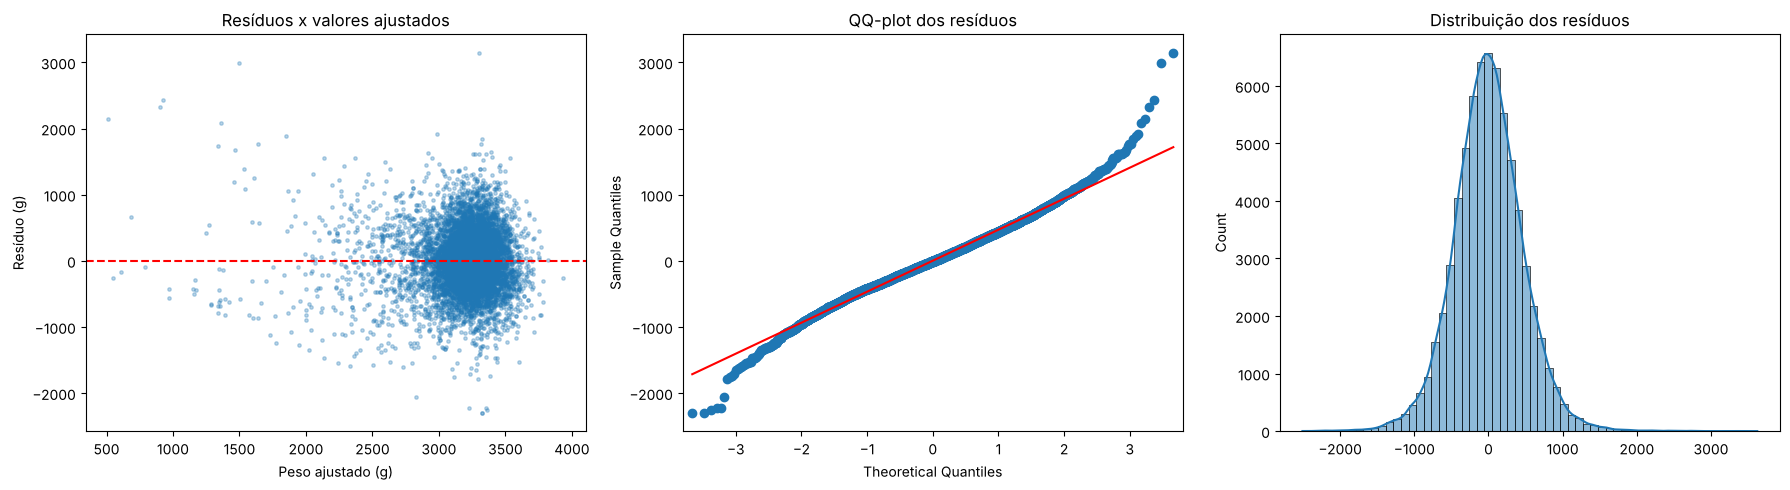

In [39]:
X = modelo.model.exog
vif = pd.DataFrame({'variável': modelo.model.exog_names, 'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]})
vif = vif[vif['variável'] != 'Intercept'].round(2)
bp = het_breuschpagan(modelo.resid, modelo.model.exog)
print(vif.to_string(index=False))
print(f'Breusch-Pagan: LM = {bp[0]:.1f} | p = {bp[1]:.3e}')
print(f'Assimetria dos resíduos = {stats.skew(modelo.resid):.3f} | curtose = {stats.kurtosis(modelo.resid):.3f}')

amostra_idx = df.sample(8000, random_state=42).index
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))
eixos[0].scatter(modelo.fittedvalues[amostra_idx], modelo.resid[amostra_idx], s=6, alpha=0.3)
eixos[0].axhline(0, color='red', linestyle='--')
eixos[0].set_title('Resíduos x valores ajustados')
eixos[0].set_xlabel('Peso ajustado (g)')
eixos[0].set_ylabel('Resíduo (g)')
sm.qqplot(modelo.resid[amostra_idx], line='s', ax=eixos[1])
eixos[1].set_title('QQ-plot dos resíduos')
sns.histplot(modelo.resid, bins=60, kde=True, ax=eixos[2])
eixos[2].set_title('Distribuição dos resíduos')
plt.tight_layout()
plt.show()

### Interpretação do modelo e diagnóstico

O modelo completo (M3) tem R² de 0,268, R² ajustado de 0,268 e F de 3.100,7 com 8 e 67.651 graus de liberdade (p < 0,001), ou seja, o conjunto de variáveis explica o peso melhor que apenas a média. O erro padrão residual é de 466 g. Cada acréscimo de complexidade melhora o R² de teste (0,219 em M1, 0,227 em M2 e 0,275 em M3) e reduz o RMSE de teste de 483 g para 465 g, contra 546 g da referência. O R² de teste ficou próximo do de treino (0,275 contra 0,266) e a validação cruzada deu 0,268 com desvio de 0,015, então não há sinal de sobreajuste.

Os coeficientes, mantendo as demais variáveis constantes:

- Cada semana a mais de gestação acrescenta cerca de 91 g perto das 38 semanas, com a curvatura negativa das semanas ao quadrado reduzindo o ganho depois do termo.
- A gravidez múltipla reduz o peso em 656 g (IC 95%: -680 a -632 g).
- Meninos pesam 109 g a mais que meninas.
- Cada consulta de pré-natal está associada a 10,5 g a mais (IC 95%: 9,4 a 11,6 g).
- Cada filho vivo anterior soma 31 g, e cada ano de idade da mãe soma 2,4 g.
- O parto cesáreo está associado a 97 g a mais, o que reflete em parte a cesárea programada em bebês maiores e não um efeito do parto sobre o peso.

Pelos coeficientes padronizados, a ordem de importância é: semanas (0,38), gravidez múltipla (-0,16), sexo (0,10), cesárea (0,09), filhos vivos (0,08) e consultas (0,07).

**Pressupostos.** O VIF fica abaixo de 1,6 em todas as variáveis, então não há multicolinearidade preocupante. O teste de Breusch-Pagan rejeita a variância constante dos resíduos, por isso os erros padrão e os ICs da tabela usam o estimador robusto HC3, que continua válido com heterocedasticidade. Os resíduos têm assimetria de 0,12 e curtose em excesso de 1,47, ou seja, são bem próximos de simétricos, com caudas um pouco mais pesadas que a normal. Com 67 mil observações, isso não compromete a inferência sobre os coeficientes. O gráfico de resíduos contra ajustados mostra a variância maior nos pesos baixos, que é a causa da heterocedasticidade.

**Limite do modelo.** Mais de 70% da variação do peso fica sem explicação, porque o SINASC não traz fatores importantes como saúde da mãe, tabagismo, hipertensão, diabetes e condição socioeconômica.

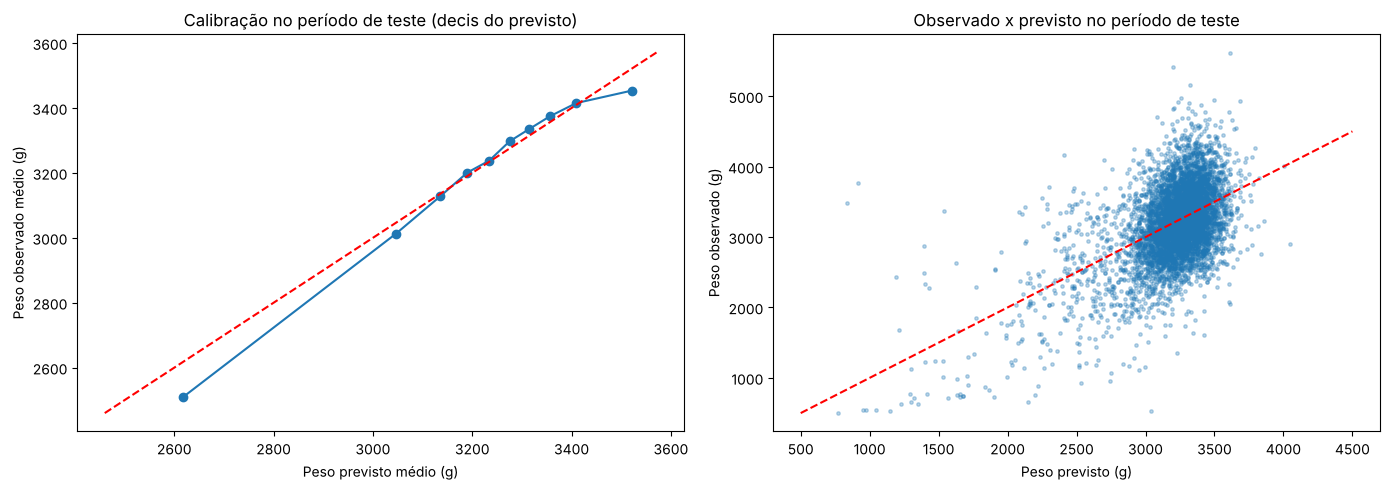

,previsto,observado,n
MES,,,
7,3207.4,3188.3,9099
8,3214.2,3209.8,5360


In [40]:
ajuste_treino = smf.ols(formulas['M3: completo'], treino).fit()
teste = teste.assign(PREVISTO=ajuste_treino.predict(teste))
teste = teste.assign(DECIL=pd.qcut(teste['PREVISTO'], 10, labels=False))
calibracao = teste.groupby('DECIL').agg(previsto=('PREVISTO', 'mean'), observado=('PESO', 'mean'))
mensal = teste.groupby('MES').agg(previsto=('PREVISTO', 'mean'), observado=('PESO', 'mean'), n=('PESO', 'size'))

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
eixos[0].plot(calibracao['previsto'], calibracao['observado'], 'o-')
limites = [calibracao.min().min() - 50, calibracao.max().max() + 50]
eixos[0].plot(limites, limites, 'r--')
eixos[0].set_title('Calibração no período de teste (decis do previsto)')
eixos[0].set_xlabel('Peso previsto médio (g)')
eixos[0].set_ylabel('Peso observado médio (g)')
eixos[1].scatter(teste['PREVISTO'].sample(6000, random_state=42), teste['PESO'].loc[teste['PREVISTO'].sample(6000, random_state=42).index], s=6, alpha=0.3)
eixos[1].plot([500, 4500], [500, 4500], 'r--')
eixos[1].set_title('Observado x previsto no período de teste')
eixos[1].set_xlabel('Peso previsto (g)')
eixos[1].set_ylabel('Peso observado (g)')
plt.tight_layout()
plt.show()
mensal.round(1)

In [41]:
cenarios = pd.DataFrame({
    'descricao': ['Termo, menino, 39 semanas, 8 consultas', 'Termo, menina, 39 semanas, 8 consultas', 'Termo, menina, 39 semanas, 2 consultas',
                  'Prematuro tardio, menina, 34 semanas, 5 consultas', 'Gemelar, menina, 36 semanas, 8 consultas', 'Pós-termo, menino, 41 semanas, 8 consultas'],
    'SEMAGESTAC': [39, 39, 39, 34, 36, 41],
    'SEXO_M': [1, 0, 0, 0, 0, 1],
    'CONSPRENAT': [8, 8, 2, 5, 8, 8],
    'MULTIPLA': [0, 0, 0, 0, 1, 0],
    'IDADEMAE': [26, 26, 26, 26, 26, 26],
    'QTDFILVIVO': [1, 1, 1, 1, 1, 1],
    'CESAREA': [0, 0, 0, 1, 1, 0],
})
cenarios['SEM_C'] = cenarios['SEMAGESTAC'] - 38
cenarios['SEM_C2'] = cenarios['SEM_C'] ** 2
previsao = modelo.get_prediction(cenarios).summary_frame(alpha=0.05)
previsao.insert(0, 'cenário', cenarios['descricao'])
previsao[['cenário', 'mean', 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper']].round(0)

,cenário,mean,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,"Termo, menino, 39 semanas, 8 consultas",3269.0,3262.0,3276.0,2355.0,4184.0
1,"Termo, menina, 39 semanas, 8 consultas",3160.0,3153.0,3167.0,2246.0,4074.0
2,"Termo, menina, 39 semanas, 2 consultas",3097.0,3088.0,3107.0,2183.0,4011.0
3,"Prematuro tardio, menina, 34 semanas, 5 consultas",2732.0,2722.0,2741.0,1818.0,3646.0
4,"Gemelar, menina, 36 semanas, 8 consultas",2320.0,2293.0,2347.0,1406.0,3235.0
5,"Pós-termo, menino, 41 semanas, 8 consultas",3431.0,3422.0,3440.0,2517.0,4345.0


### Previsão

A calibração por decil e o gráfico de observado contra previsto mostram se o peso previsto acompanha o observado no período de teste. Nos dois meses de teste, o peso médio previsto (3.207 g em julho e 3.214 g em agosto) ficou próximo do observado (3.188 g e 3.210 g), com diferença de até 19 g. A tabela de cenários mostra a previsão pontual, o IC 95% da média e o intervalo de previsão 95% para um bebê individual. O intervalo de previsão é muito mais largo (mais de 1.800 g de amplitude) porque inclui a variação entre bebês, enquanto o IC da média inclui só a incerteza da estimativa. Por exemplo, para um menino a termo com 39 semanas e 8 consultas, a média prevista é de 3.269 g (IC da média: 3.262 a 3.276 g), mas um bebê individual nessas condições pode pesar de 2.355 a 4.184 g.

Na última tabela, o coeficiente das consultas cai de 10,5 g para 7,7 g por consulta quando só entram os nascimentos com 37 semanas ou mais. A queda é esperada, porque parte do efeito aparente nos dados completos vem de gestações mais longas terem mais consultas. O efeito de 7,7 g continua diferente de zero (IC 95%: 6,6 a 8,8 g), então usei os dois valores como limite superior e inferior nas simulações.

In [42]:
termo_modelo = smf.ols('PESO ~ SEM_C + SEM_C2 + MULTIPLA + SEXO_M + CONSPRENAT + IDADEMAE + QTDFILVIVO + CESAREA', df[df['SEMAGESTAC'] >= 37]).fit(cov_type='HC3')
comparacao_consultas = pd.DataFrame({
    'Amostra': ['Todos os nascimentos', '37 semanas ou mais'],
    'Coef. de consultas (g por consulta)': [modelo_hc3.params['CONSPRENAT'], termo_modelo.params['CONSPRENAT']],
    'IC 95% inf.': [modelo_hc3.conf_int().loc['CONSPRENAT', 0], termo_modelo.conf_int().loc['CONSPRENAT', 0]],
    'IC 95% sup.': [modelo_hc3.conf_int().loc['CONSPRENAT', 1], termo_modelo.conf_int().loc['CONSPRENAT', 1]],
    'n': [len(df), int((df['SEMAGESTAC'] >= 37).sum())],
}).round(3)
comparacao_consultas

,Amostra,Coef. de consultas (g por consulta),IC 95% inf.,IC 95% sup.,n
0,Todos os nascimentos,10.516,9.396,11.636,67660
1,37 semanas ou mais,7.708,6.608,8.808,58859


## Contexto, soluções propostas e validação

**Contexto.** A taxa de baixo peso no Pará neste período é de 8,3% e a de prematuridade é de 13,0%, e 20% dos nascimentos tiveram menos de 6 consultas de pré-natal, o mínimo recomendado pelo Ministério da Saúde. O pré-natal é o ponto em que o sistema de saúde consegue agir antes do parto, e foi onde os testes encontraram diferença relevante.

**Solução 1: ampliar o pré-natal até pelo menos 6 consultas, começando pelos municípios com maior inadequação.** Validação: H2 mostra que o baixo peso é quase o dobro sem pré-natal adequado (RR de 1,95); H4 mostra que o peso médio sobe a cada faixa de consultas; a regressão estima de 7,7 a 10,5 g por consulta adicional, com IC que não inclui zero; e H7 mostra que a inadequação varia de 15% a 42% entre municípios, o que permite priorizar. A simulação abaixo aplica o coeficiente às mães com menos de 6 consultas. Resultado: 13.840 mães, ganho médio de 19 a 26 g e redução de 60 a 90 casos de baixo peso entre 1.870, ou 3,2% a 4,8%.

**Solução 2: acompanhamento de alto risco para gestações múltiplas.** Validação: H5 mostra uma diferença de 931 g (d = -1,75) e a regressão estima -656 g com as demais variáveis controladas. Gestações múltiplas são 1,7% dos nascimentos, mas 13,1% dos casos de baixo peso e 8,1% dos prematuros, com 62,8% de baixo peso contra 7,3% nas gestações únicas. É o menor grupo com o maior retorno por caso atendido.

**Solução 3: reforçar a capacidade de parto de risco nos municípios que encaminham gestantes.** Validação: H6 mostra prematuridade de 16,8% fora do município contra 11,6% dentro (RR de 1,44), o que indica que os partos de maior risco já estão sendo deslocados. Investir em leitos neonatais e transporte materno regional reduz o deslocamento do parto de risco.

In [43]:
abaixo = df['CONSPRENAT'] < 6
faltam = (6 - df.loc[abaixo, 'CONSPRENAT'])
linhas = []
for rotulo, coef in [('Coeficiente de todos os nascimentos', modelo_hc3.params['CONSPRENAT']), ('Coeficiente de 37 semanas ou mais (conservador)', termo_modelo.params['CONSPRENAT'])]:
    peso_novo = df.loc[abaixo, 'PESO'] + coef * faltam
    baixo_antes = (df.loc[abaixo, 'PESO'] < 2500).sum()
    baixo_depois = (peso_novo < 2500).sum()
    linhas.append({'Cenário': rotulo, 'Mães com menos de 6 consultas': int(abaixo.sum()), 'Ganho médio de peso (g)': (coef * faltam).mean(),
                   'Baixo peso antes': int(baixo_antes), 'Baixo peso depois': int(baixo_depois), 'Casos evitados': int(baixo_antes - baixo_depois),
                   'Redução relativa (%)': (baixo_antes - baixo_depois) / baixo_antes * 100})
impacto_prenatal = pd.DataFrame(linhas).round(2)
impacto_prenatal

,Cenário,Mães com menos de 6 consultas,Ganho médio de peso (g),Baixo peso antes,Baixo peso depois,Casos evitados,Redução relativa (%)
0,Coeficiente de todos os nascimentos,13840,25.63,1870,1780,90,4.81
1,Coeficiente de 37 semanas ou mais (conservador),13840,18.78,1870,1810,60,3.21


In [44]:
alvo = df[df['MULTIPLA'] == 1]
print(f'Gestações múltiplas: {len(alvo)} ({len(alvo) / len(df) * 100:.2f}% dos nascimentos)')
print(f"Baixo peso: {alvo['BAIXO_PESO'].mean() * 100:.1f}% | prematuridade: {alvo['PREMATURO'].mean() * 100:.1f}%")
print(f"Baixo peso nas únicas: {df.loc[df['MULTIPLA'] == 0, 'BAIXO_PESO'].mean() * 100:.1f}% | prematuridade nas únicas: {df.loc[df['MULTIPLA'] == 0, 'PREMATURO'].mean() * 100:.1f}%")
print(f"Parcela dos baixo peso que vêm de gestação múltipla: {alvo['BAIXO_PESO'].sum() / df['BAIXO_PESO'].sum() * 100:.1f}%")
print(f"Parcela dos prematuros que vêm de gestação múltipla: {alvo['PREMATURO'].sum() / df['PREMATURO'].sum() * 100:.1f}%")
print(f"Cesárea geral: {df['CESAREA'].mean() * 100:.1f}% | cesárea a termo: {termo_df['CESAREA'].mean() * 100:.1f}%")
print(f"Cesárea por município (maiores): ")
print(resumo_mun['pct_cesarea'].sort_values(ascending=False))

Gestações múltiplas: 1167 (1.72% dos nascimentos)
Baixo peso: 62.8% | prematuridade: 61.4%
Baixo peso nas únicas: 7.3% | prematuridade nas únicas: 12.2%
Parcela dos baixo peso que vêm de gestação múltipla: 13.1%
Parcela dos prematuros que vêm de gestação múltipla: 8.1%
Cesárea geral: 63.6% | cesárea a termo: 64.1%
Cesárea por município (maiores): 
CODMUNRES
150240    71.96
150010    68.84
150140    68.76
150080    68.49
150420    66.81
150553    62.32
150680    59.72
150180    39.39
Name: pct_cesarea, dtype: float64


## Conclusões e limitações

**O que os dados mostram.** A idade gestacional é o principal determinante do peso ao nascer (beta padronizado de 0,38). Depois dela, a gravidez múltipla é o fator de maior efeito. O pré-natal tem efeito pequeno por consulta, mas a diferença no risco de baixo peso entre pré-natal adequado e inadequado é grande (13,5% contra 7,0%). As diferenças entre municípios na cobertura de pré-natal são grandes, e as taxas de cesárea chegam a 68% a 72% nos municípios maiores, contra 39% no município de código 150180.

**Impacto das decisões.** Ampliar o pré-natal tem impacto modesto sobre o baixo peso (3% a 5% dos casos), porque as consultas explicam pouco da variação do peso. O acompanhamento de gestações múltiplas tem o maior impacto por caso. As soluções se complementam e a primeira tem a vantagem de alcançar mais gestantes.

**Limitações.**

- Os dados são observacionais, então os coeficientes mostram associação e não causa. O número de consultas depende da duração da gestação (causalidade reversa), e por isso a simulação usa dois coeficientes e deve ser lida como estimativa, não como previsão de resultado de uma política.
- O R² de 0,27 mostra que o modelo explica pouco da variação individual. O intervalo de previsão de 95% é largo, então o modelo serve para análise populacional, e não para decidir sobre um bebê.
- A base cobre apenas janeiro a agosto de 2026, com agosto parcial, e o teste temporal usa só dois meses. Não é possível avaliar sazonalidade.
- Removi 7,8% das linhas por ausentes e 0,16% por valores impossíveis. A comparação feita mostrou diferenças pequenas (d de Cohen de 0,056), mas as linhas excluídas tinham mais nascimentos fora do município.
- Os limiares usados para valores impossíveis e para as faixas de baixo peso e prematuridade são escolhas minhas, embasadas na literatura clínica e nos dados.
- Com n grande, qualquer diferença vira significativa. Por isso a interpretação se apoia em tamanhos de efeito e intervalos de confiança, e não só em p-valores.
- O SINASC não traz saúde materna, hábitos nem renda, que provavelmente explicam boa parte da variação não explicada.

**Dashboard.** Os resultados acima foram exportados para o dashboard interativo, que permite filtrar a base e explorar as mesmas análises.

In [45]:
import json

principais = df['CODMUNRES'].value_counts().head(12).index.tolist()
nomes_mun = {150140: 'Belém', 150680: 'Santarém', 150080: 'Ananindeua', 150553: 'Parauapebas', 150420: 'Marabá', 150240: 'Castanhal'}
rotulos = [nomes_mun.get(c, f'Cód. {c}') for c in principais] + ['Demais municípios']
mun_idx = df['CODMUNRES'].map({c: i for i, c in enumerate(principais)}).fillna(len(principais)).astype(int)

registros = {
    'mes': (df['MES'] - 1).tolist(),
    'sexo': df['SEXO_M'].tolist(),
    'idade': df['IDADEMAE'].tolist(),
    'parto': df['CESAREA'].astype(int).tolist(),
    'multipla': df['MULTIPLA'].tolist(),
    'semanas': df['SEMAGESTAC'].tolist(),
    'peso': df['PESO'].astype(int).tolist(),
    'consultas': df['CONSPRENAT'].astype(int).tolist(),
    'faixaConsultas': (df['CONSULTAS'].astype(int) - 1).tolist(),
    'filhos': df['QTDFILVIVO'].astype(int).tolist(),
    'apgar5': df['APGAR5'].astype(int).tolist(),
    'municipio': mun_idx.tolist(),
    'foraMun': df['NASCEU_FORA_MUN_RES'].tolist(),
}

amostra_obs = teste.sample(1500, random_state=1)
dados_dash = {
    'registros': registros,
    'municipios': rotulos,
    'modelo': {
        'variaveis': list(modelo.params.index),
        'coef': modelo.params.round(6).tolist(),
        'sigma': float(np.sqrt(modelo.scale)),
        'gl_resid': int(modelo.df_resid),
        'gl_modelo': int(modelo.df_model),
        'r2': float(modelo.rsquared),
        'r2_ajustado': float(modelo.rsquared_adj),
        'f': float(modelo.fvalue),
        'tabela': [
            {'variavel': v, 'coef': float(tabela_coef.loc[v, 'Coeficiente']), 'ep': float(tabela_coef.loc[v, 'Erro padrão (HC3)']), 't': float(tabela_coef.loc[v, 't']),
             'p': float(tabela_coef.loc[v, 'p-valor']), 'inf': float(tabela_coef.loc[v, 'IC 95% inf.']), 'sup': float(tabela_coef.loc[v, 'IC 95% sup.']),
             'beta': None if pd.isna(tabela_coef.loc[v, 'Beta padronizado']) else float(tabela_coef.loc[v, 'Beta padronizado'])}
            for v in tabela_coef.index
        ],
        'vif': {r['variável']: float(r['VIF']) for _, r in vif.iterrows()},
        'comparacao': comparacao_modelos.to_dict(orient='records'),
        'cv': {'r2_medio': float(r2_cv.mean()), 'r2_dp': float(r2_cv.std()), 'rmse_medio': float(rmse_cv.mean())},
        'calibracao': calibracao.reset_index().to_dict(orient='records'),
        'obsPrev': {'previsto': amostra_obs['PREVISTO'].round(1).tolist(), 'observado': amostra_obs['PESO'].astype(int).tolist()},
        'residuos': {'ajustado': modelo.fittedvalues[amostra_idx].round(1).tolist()[:2000], 'residuo': modelo.resid[amostra_idx].round(1).tolist()[:2000]},
    },
    'testes': json.loads(pd.DataFrame(resultados).assign(**{'p-valor': [float(x) for x in [float(v) for v in tabela_testes['p-valor']]]}).to_json(orient='records')),
    'impacto': impacto_prenatal.to_dict(orient='records'),
    'impacto_coef': {'todos': float(modelo_hc3.params['CONSPRENAT']), 'termo': float(termo_modelo.params['CONSPRENAT'])},
}

with open('dashboard_dados.json', 'w', encoding='utf-8') as arquivo:
    json.dump(dados_dash, arquivo, ensure_ascii=False, separators=(',', ':'))
print(f'dashboard_dados.json gravado')

dashboard_dados.json gravado
